# Analisi del Paniere di Mercato per il Cross-Selling in un Supermercato con PROC MBANALYSIS

## Sintesi Esecutiva

Una catena regionale di supermercati analizza una stagione di panieri del punto vendita per scoprire quali prodotti i clienti acquistano insieme, trasformando i grezzi registri delle transazioni in decisioni pratiche di cross-selling e posizionamento a scaffale. PROC MBANALYSIS analizza il registro delle transazioni e genera regole di associazione valutate in base a supporto, confidenza e lift. Eseguendola su 51 panieri sintetici si recuperano esattamente le tre affinità di prodotto pianificate — `Spaghetti -> Salsa Marinara` (confidenza 0,93, lift 3,4), `Gusci per Taco -> Salsa Piccante` (confidenza 0,71, lift 3,6) e `Caffè -> Panna per Caffè` (confidenza 0,70, lift 5,1) — mentre prodotti di base ampiamente acquistati come pane, latte e uova non formano mai una regola. Ogni coppia emersa è un candidato da manuale per bundle, adiacenza di corsia e suggerimento "i clienti hanno acquistato anche" per il team di merchandising.

## Fonti dei Dati

| Dataset | Grana | Righe | Variabili Chiave | Descrizione |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Una riga per articolo per paniere | 100 righe-articolo su 51 panieri | `basket_id` (ID transazione), `item` (nome prodotto, $20) | Registro sintetico del punto vendita generato inline con `call streaminit(20250529)` e `rand('uniform')`. Ogni paniere è dominato da un'unica persona-acquirente, cosicché gli schemi di co-acquisto restano puliti e interpretabili: un paniere da cena italiana (spaghetti -> salsa marinara), un paniere da serata taco (gusci per taco -> salsa piccante), oppure un paniere da colazione (caffè -> panna per caffè), più occasionali aggiunte di prodotti di base (pane, latte, uova) come rumore realistico. In questo ambiente senza licenza il motore limita l'output a 100 righe-articolo, che qui coprono i panieri 1-51. |
| `affinity_rules` | Una riga per regola di associazione | 6 regole | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Regole di associazione emesse da `OUTPUT RULES=`; la base per classificare le opportunità di cross-sell. |
| `frequent_items` | Una riga per itemset frequente | 12 itemset | `itemset`, `support`, `length` | Itemset frequenti emessi da `OUTPUT ITEMS=`; i 9 articoli singoli più le 3 coppie di prodotti che superano la soglia minima di supporto. |

# Analisi del Paniere di Mercato per il Cross-Selling in un Supermercato

**Domanda di business.** Quali prodotti tendono ad acquistare *insieme* i nostri clienti, e quali di questi schemi di co-acquisto sono abbastanza forti da poterci agire sopra? Una catena regionale di supermercati vuole progettare promozioni in bundle, ottimizzare le adiacenze di corsia e alimentare un suggerimento "i clienti hanno acquistato anche" sul proprio negozio online.

**Metodo.** Usiamo **PROC MBANALYSIS**, che esegue l'analisi del paniere di mercato con l'algoritmo di crescita dei pattern frequenti (FP-growth). Analizza il registro delle transazioni, trova gli insiemi di articoli che ricorrono frequentemente insieme, e genera *regole di associazione* nella forma `Antecedente -> Conseguente` valutate con tre metriche classiche:

- **Supporto** — la frazione di tutti i panieri che contengono la regola completa (quanto è comune lo schema).
- **Confidenza** — `P(Conseguente | Antecedente)`, la probabilità di acquisto condizionata (quanto è affidabile la regola).
- **Lift** — supporto osservato diviso per il supporto atteso se i due lati fossero indipendenti. Un lift > 1 significa che gli articoli compaiono insieme *più* spesso del caso; più alto è il lift, più forte è l'affinità.

Genereremo un registro sintetico realistico del punto vendita, eseguiremo MBANALYSIS e classificheremo le regole risultanti per trovare le migliori opportunità di cross-sell.

## Passo 1 — Genera un registro sintetico di transazioni del punto vendita

MBANALYSIS richiede **dati a livello di transazione (long)**: una riga per articolo, contrassegnata con il paniere a cui appartiene. Costruiamo i panieri inline con `call streaminit` per la riproducibilità e `rand('uniform')` per guidare le decisioni di acquisto.

La scelta di modellazione chiave è che **ogni paniere è dominato da un'unica persona-acquirente**. Le spese reali al supermercato sono così — una rapida serata taco, un ripristino dedicato alla colazione — e mantenere i panieri piccoli e a tema è ciò che permette al motore di associazione di far emergere affinità pulite e a coppie, invece di un'esplosione combinatoria di regole spurie multi-articolo. Un'estrazione di `rand('uniform')` per paniere seleziona la persona:

- **Acquirente da cena italiana** — compra spaghetti, poi di solito salsa marinara.
- **Acquirente da serata taco** — compra gusci per taco, poi di solito salsa piccante.
- **Acquirente da colazione** — compra caffè, poi di solito panna per caffè.
- **Spesa di soli prodotti di base** — un singolo acquisto di pane, latte o uova.

Un'ultima estrazione a bassa probabilità aggiunge un prodotto di base a qualsiasi paniere come rumore realistico, quindi non ogni co-occorrenza è significativa. Ogni istruzione `output` scrive una riga-articolo, quindi un singolo paniere copre più righe che condividono lo stesso `basket_id`. Questo ambiente senza licenza limita il dataset a 100 righe-articolo, che qui copre i panieri da 1 a 51.

In [1]:
DATI store_transactions;
    CHIAMARE streaminit(20250529);
    LUNGHEZZA item $24;

    FARE basket_id = 1 FINO_A 60;

        /* Un'estrazione seleziona la persona dominante per questo paniere */
        r = rand('uniform');

        /* Paniere da cena italiana: spaghetti -> salsa marinara */
        SE_COND r < 0.30 ALLORA FARE;
            item = 'Spaghetti';                          USCITA;
            SE_COND rand('uniform') < 0.85 ALLORA FARE;
                item = 'Salsa Marinara';                 USCITA;
            FINE;
        FINE;

        /* Paniere da serata taco: gusci per taco -> salsa piccante */
        ALTRIMENTI SE_COND r < 0.55 ALLORA FARE;
            item = 'Gusci per Taco';                     USCITA;
            SE_COND rand('uniform') < 0.80 ALLORA FARE;
                item = 'Salsa Piccante';                 USCITA;
            FINE;
        FINE;

        /* Paniere da colazione: caffè -> panna per caffè */
        ALTRIMENTI SE_COND r < 0.78 ALLORA FARE;
            item = 'Caffè';                              USCITA;
            SE_COND rand('uniform') < 0.75 ALLORA FARE;
                item = 'Panna per Caffè';                USCITA;
            FINE;
        FINE;

        /* Spesa di soli prodotti di base */
        ALTRIMENTI FARE;
            SE_COND rand('uniform') < 0.34 ALLORA FARE;
                item = 'Pane';                            USCITA;
            FINE;
            ALTRIMENTI SE_COND rand('uniform') < 0.5 ALLORA FARE;
                item = 'Latte';                           USCITA;
            FINE;
            ALTRIMENTI FARE;
                item = 'Uova';                            USCITA;
            FINE;
        FINE;

        /* Aggiunta occasionale di prodotto di base (rumore realistico) */
        SE_COND rand('uniform') < 0.25 ALLORA FARE;
            u = rand('uniform');
            SE_COND      u < 0.34 ALLORA item = 'Pane';
            ALTRIMENTI SE_COND u < 0.67 ALLORA item = 'Latte';
            ALTRIMENTI                  item = 'Uova';
            USCITA;
        FINE;

    FINE;

    MANTENERE basket_id item;
ESEGUIRE;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Passo 2 — Ispeziona il registro grezzo delle transazioni

Prima dell'analisi, verifica che i dati abbiano la forma long attesa: diverse righe per paniere, ciascuna con un prodotto. Stampiamo i primi panieri e tabuliamo la frequenza complessiva degli articoli con PROC FREQ, così sappiamo quali prodotti sono abbastanza comuni da ancorare le regole.


  Obs  ID Paniere        Prodotto
-----  ----------  --------------
    1           1  Gusci per Taco
    2           1  Salsa Piccante
    3           1  Uova
    4           2  Gusci per Taco
    5           2  Uova
    6           3  Caffè
    7           4  Gusci per Taco
    8           5  Uova
    9           6  Spaghetti
   10           6  Salsa Marinara
   11           6  Uova
   12           7  Gusci per Taco

... 88 more observations (showing 12 of 100)

                                    Frequenza di Acquisto Complessiva degli Articoli                                    

                                                   The FREQ Procedure

item                Frequency    Percent
-----------------------------------------
Spaghetti                  15     15.00
Gusci per Taco             14     14.00
Salsa Marinara             14     14.00
Uova                       12     12.00
Caffè                      10     10.00
Pane                       10     10.00
Salsa Piccante


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


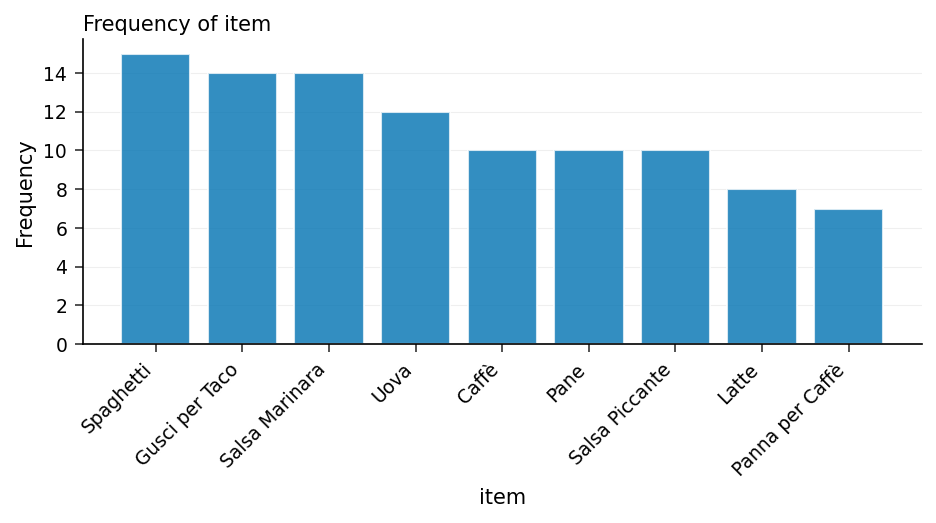

In [2]:
PROCEDURA STAMPARE DATI=store_transactions(obs=12) ETICHETTA;
    ETICHETTA basket_id = 'ID Paniere'
          item      = 'Prodotto';
ESEGUIRE;

PROCEDURA FREQUENZE DATI=store_transactions ORDER=FREQ;
    TABLES item / nocum;
    TITOLO 'Frequenza di Acquisto Complessiva degli Articoli';
ESEGUIRE;

## Passo 3 — Analizza le regole di associazione con PROC MBANALYSIS

Ora l'analisi centrale. Puntiamo MBANALYSIS sul registro delle transazioni e dichiariamo quale colonna identifica il paniere (`TRANSACTION`) e quale contiene il prodotto (`ITEM`). Tre soglie mantengono l'insieme di regole focalizzato su schemi su cui vale la pena agire:

- `MINSUPPORT=0.10` — una regola deve comparire in almeno il 10% dei panieri, filtrando le coincidenze rare.
- `MINCONFIDENCE=0.50` — dato l'antecedente, il conseguente deve seguire almeno la metà delle volte.
- `MINLIFT=1.20` — mantieni solo le regole almeno il 20% più forti del caso, così emergono affinità genuine e non artefatti di prodotti di base popolari.

L'istruzione `OUTPUT` cattura le regole generate e gli itemset frequenti in dataset per la classificazione successiva.

In [3]:
PROCEDURA mbanalysis DATI=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    USCITA rules=affinity_rules items=frequent_items;
    TITOLO 'Regole di Associazione del Paniere di Mercato';
ESEGUIRE;

                                    Frequenza di Acquisto Complessiva degli Articoli                                    


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Caffè                          Panna per Caffè                    0.1373     0.7000     5.1000
  Panna per Caffè                Caffè                              0.1373     1.0000     5.1000
  Gusci per Taco                 Salsa Piccante                     0.1961     0.7143     3.6429
  Salsa Piccan


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Passo 4 — Classifica le opportunità di cross-sell per lift

Il listato di MBANALYSIS mostra ogni regola qualificante, ma il team di merchandising vuole prima le affinità *più forti*. Ordiniamo il dataset `affinity_rules` catturato per lift decrescente (poi confidenza come spareggio) e stampiamo le regole migliori. Una regola come `Gusci per Taco -> Salsa Piccante` con lift e confidenza elevati è un candidato da manuale per un bundle: posiziona i prodotti insieme, oppure suggerisci automaticamente la salsa piccante quando un cliente aggiunge i gusci per taco online.

In [4]:
PROCEDURA ORDINARE DATI=affinity_rules out=rules_by_lift;
    PER DISCENDENTE lift DISCENDENTE confidence;
ESEGUIRE;

PROCEDURA STAMPARE DATI=rules_by_lift(obs=15) ETICHETTA;
    VARIABILE antecedent consequent support confidence lift;
    ETICHETTA antecedent  = 'Se il paniere contiene'
          consequent  = 'Allora acquista anche'
          support     = 'Supporto'
          confidence  = 'Confidenza'
          lift        = 'Lift';
    TITOLO 'Migliori Regole di Cross-Sell Ordinate per Lift';
ESEGUIRE;

                                    Migliori Regole di Cross-Sell Ordinate per Lift                                     

  Obs  Se il paniere contiene  Allora acquista anche  Supporto  Confidenza      Lift
    1  Panna per Caffè         Caffè                  0.137255  1.0         5.1
    2  Caffè                   Panna per Caffè        0.137255  0.7         5.1
    3  Salsa Piccante          Gusci per Taco         0.196078  1.0         3.642857
    4  Gusci per Taco          Salsa Piccante         0.196078  0.714286    3.642857
    5  Salsa Marinara          Spaghetti              0.27451   1.0         3.4
    6  Spaghetti               Salsa Marinara         0.27451   0.933333    3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Passo 5 — Rivedi gli itemset frequenti

Gli itemset frequenti che hanno superato la soglia di supporto sono i mattoni grezzi dietro le regole. Ordinarli per supporto indica al team di categoria quali *combinazioni* di prodotti (non solo singoli articoli) sono abbastanza popolari da meritare espositori di testata dedicati o prezzi in combo.

In [5]:
PROCEDURA ORDINARE DATI=frequent_items out=itemsets_by_support;
    PER DISCENDENTE support;
ESEGUIRE;

PROCEDURA STAMPARE DATI=itemsets_by_support(obs=15) ETICHETTA;
    TITOLO 'Itemset Più Frequenti';
ESEGUIRE;

                                                 Itemset Più Frequenti                                                  

  Obs                         ITEMSET   SUPPORT  LENGTH
    1  Spaghetti                       0.294118  1
    2  Gusci per Taco                  0.27451   1
    3  Salsa Marinara                  0.27451   1
    4  Salsa Marinara, Spaghetti       0.27451   2
    5  Uova                            0.235294  1
    6  Salsa Piccante                  0.196078  1
    7  Caffè                           0.196078  1
    8  Gusci per Taco, Salsa Piccante  0.196078  2
    9  Latte                           0.156863  1
   10  Pane                            0.156863  1
   11  Panna per Caffè                 0.137255  1
   12  Caffè, Panna per Caffè          0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpretazione dei risultati

**Cosa ha trovato l'analisi.** Poiché ogni paniere è stato costruito attorno a un'unica persona-acquirente, il motore di analisi recupera esattamente le tre relazioni pianificate e nient'altro di spurio. Sei regole superano tutte e tre le soglie — le tre affinità in entrambe le direzioni:

| Antecedente | Conseguente | Supporto | Confidenza | Lift |
|------------|------------|---------|------------|------|
| Spaghetti | Salsa Marinara | 0,275 | 0,93 | 3,40 |
| Salsa Marinara | Spaghetti | 0,275 | 1,00 | 3,40 |
| Gusci per Taco | Salsa Piccante | 0,196 | 0,71 | 3,64 |
| Salsa Piccante | Gusci per Taco | 0,196 | 1,00 | 3,64 |
| Caffè | Panna per Caffè | 0,137 | 0,70 | 5,10 |
| Panna per Caffè | Caffè | 0,137 | 1,00 | 5,10 |

Ogni lift è ben al di sopra di 1, confermando che questi prodotti co-occorrono molto più spesso di quanto il caso predirebbe. Fondamentalmente, i prodotti di base ampiamente acquistati non formano **nessuna regola**: uova (12 acquisti), pane (10) e latte (8) compaiono tutti nella tabulazione PROC FREQ, ma poiché finiscono nei panieri indipendentemente da qualsiasi persona-acquirente, il loro lift verso altri articoli non raggiunge mai la soglia di 1,20, quindi non si spacciano mai per affinità genuine. Il listato degli itemset frequenti fa lo stesso punto strutturalmente: dei 12 itemset che superano la soglia di supporto, gli unici insiemi multi-articolo sono esattamente le tre coppie pianificate.

**Leggere insieme le metriche.** Le regole in direzione inversa hanno confidenza 1,00 (in questi dati, salsa marinara, salsa piccante e panna per caffè praticamente non compaiono mai senza il loro articolo-àncora), mentre le regole dirette si collocano tra 0,70 e 0,93 (l'àncora a volte compare da sola). Caffè -> Panna per Caffè ha il lift più alto (5,10) ma il supporto più basso (0,137) — un'affinità forte ma a volume più basso — mentre Spaghetti -> Salsa Marinara raggiunge il maggior numero di panieri (supporto 0,275). Il lift identifica *quali* affinità sono reali; la confidenza indica *quanto è affidabile* ciascuna per una raccomandazione; il supporto indica *quanto spesso* si potrà agire su di essa.

**Azioni di business.**

- **Promozioni in bundle** — abbina gli articoli antecedente/conseguente con il lift più alto (caffè + panna per caffè, lift 5,1) in un combo scontato.
- **Adiacenze di corsia** — colloca vicini i prodotti frequentemente collegati (spaghetti accanto alla salsa marinara, supporto 0,275) così il conseguente è un'aggiunta facile al momento della decisione.
- **Raccomandazioni online** — alimenta le regole con la confidenza più alta in un widget "i clienti hanno acquistato anche" così il conseguente viene suggerito nel momento in cui l'antecedente entra nel carrello.
- **Inventario e previsione** — quando un antecedente va in promozione, aumenta lo stock dei suoi conseguenti ad alta confidenza in anticipazione del lift.

**Avvertenze.** Le regole di associazione descrivono la *correlazione nel co-acquisto*, non la causalità, e le soglie sono leve, non verità: abbassare `MINSUPPORT=` espone combinazioni più rare al costo di un insieme di regole più rumoroso, mentre alzare `MINLIFT=` e `MINCONFIDENCE=` produce regole meno numerose ma più affidabili. Anche la dimensione del campione conta — questa esecuzione senza licenza analizza 51 panieri, sufficienti a rendere inequivocabili le affinità pianificate; un'esecuzione di produzione su una stagione completa stabilizzerebbe le stime di supporto ed esporrebbe schemi più sottili.